In [ ]:
!pip install -q networkx dash dash-core-components dash-html-components dash-bootstrap-components plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.5/222.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 4.5 MB/s eta 0:00:00


## KNN Regression Demo

In [ ]:
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import numpy as np
import plotly.graph_objects as go
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split

# Generate sample data
np.random.seed(0)
X = np.sort(5 * np.random.rand(40, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create Dash app
app = dash.Dash(__name__)

app.layout = html.Div([
    dcc.Graph(id='knn-graph'),
    dcc.Slider(
        id='n-neighbors-slider',
        min=1,
        max=20,
        value=5,
        marks={i: str(i) for i in range(1, 21)},
        step=1
    )
])

@app.callback(
    Output('knn-graph', 'figure'),
    [Input('n-neighbors-slider', 'value')]
)
def update_graph(n_neighbors):
    # Train KNN model
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)

    # Predict values
    X_plot = np.linspace(0, 5, 500).reshape(-1, 1)
    y_plot = knn.predict(X_plot)

    # Create Plotly figure
    fig = go.Figure()

    # Scatter plot for training data
    fig.add_trace(go.Scatter(x=X_train.ravel(), y=y_train, mode='markers',
                             marker=dict(color='red', size=8), name='Training data'))

    # Line plot for predictions
    fig.add_trace(go.Scatter(x=X_plot.ravel(), y=y_plot, mode='lines',
                             line=dict(color='blue'), name=f'KNN regression (n_neighbors={n_neighbors})'))

    # Update layout
    fig.update_layout(title=f'KNN Regression (n_neighbors={n_neighbors})',
                      xaxis_title='X',
                      yaxis_title='y',
                      showlegend=True)

    return fig

# Run the Dash app
if __name__ == '__main__':
    app.run_server(debug=False)

<IPython.core.display.Javascript object>

Important things to note:

* For small $K$ (number of neighbours), the regression function closely follows the data points (overfitting)
* For large $K$, the regression function becomes too unspecific.

## Navigable Small World (NSW) demo

Constructing an NSW point by point:

* Add a point
* Connect it with its $K$ neighbours (in our case, $K=2$)

Earlier connections establish long-range connectivity.

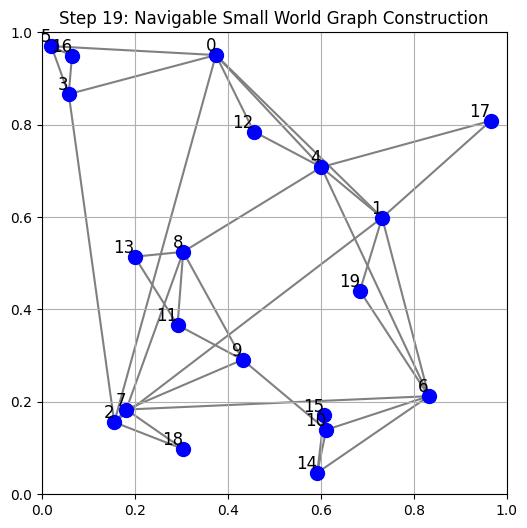

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics.pairwise import euclidean_distances
from IPython.display import clear_output
import time


# Generate a random 2D dataset
np.random.seed(42)
num_points = 20
points = np.random.rand(num_points, 2)



# Initialize an empty graph
G = nx.Graph()

# Function to calculate the k nearest neighbors of a given point
def k_nearest_neighbors(point_idx, points, k=2):
    distances = euclidean_distances([points[point_idx]], points)[0]
    nearest_neighbors = np.argsort(distances)[1:k+1]  # Skip the point itself
    return nearest_neighbors

# Function to visualize the graph at each step
def visualize_graph(points, G, step):

    plt.figure(figsize=(6, 6))

    # Draw points
    plt.scatter(points[:step+1, 0], points[:step+1, 1], color='blue', s=100, zorder=2)

    # Draw edges
    for edge in G.edges():
        point1, point2 = points[edge[0]], points[edge[1]]
        plt.plot([point1[0], point2[0]], [point1[1], point2[1]], color='gray', zorder=1)

    # Annotate points
    for idx, (x, y) in enumerate(points[:step+1]):
        plt.text(x, y, str(idx), fontsize=12, ha='right', va='bottom')

    plt.title(f"Step {step}: Navigable Small World Graph Construction")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    time.sleep(1)
    clear_output(wait=True)
    plt.show()

# Build the Navigable Small World graph incrementally
def build_nsw_graph(points, G, k=2):
    for step, point in enumerate(points):
        G.add_node(step)  # Add the new point to the graph

        if step > 0:
            # Find k nearest neighbors of the new point
            neighbors = k_nearest_neighbors(step, points[:step+1], min(k,step))

            # Connect the new point to its nearest neighbors
            for neighbor in neighbors:
                G.add_edge(step, neighbor)

        # Visualize the graph at each step
        visualize_graph(points, G, step)

# Build and visualize the Navigable Small World graph
build_nsw_graph(points, G, k=2)

Searching for the nearest neighbour of a query in an NSW:

* Pick up a random point in the NSW graph
* At a vertex $v$, choose among the vertices $u$ connected to $u$ the one which is closer to the query, and traverse to it.

Red vertex are those we've passed; green vertex is the current vertex. The query is in purple.

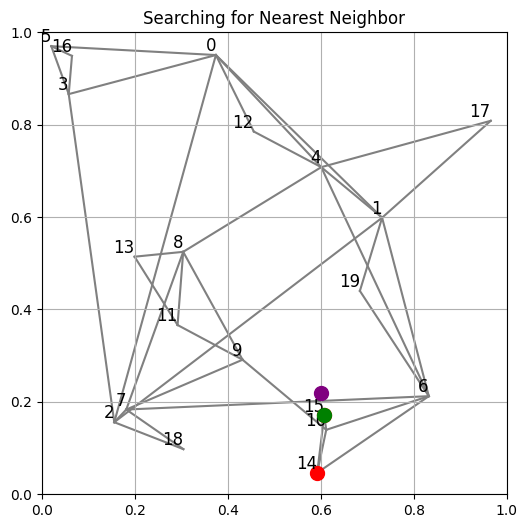

In [ ]:
# Function to visualize the search process
def visualize_search(points, G, start, query, visited):

    plt.figure(figsize=(6, 6))

    # Plot all nodes and edges
    for edge in G.edges():
        point1, point2 = points[edge[0]], points[edge[1]]
        plt.plot([point1[0], point2[0]], [point1[1], point2[1]], color='gray', zorder=1)

    # Plot visited nodes in red
    for v in visited:
        plt.scatter(points[v, 0], points[v, 1], color='red', s=100, zorder=2)

    # Annotate points
    for idx, (x, y) in enumerate(points):
        plt.text(x, y, str(idx), fontsize=12, ha='right', va='bottom')

    # Highlight the current point point in green
    plt.scatter(points[start, 0], points[start, 1], color='green', s=100, zorder=3, label="Start")

    # Plot the query point in purple
    plt.scatter(query[0], query[1], color='purple', s=100, zorder=4, label="Query")

    plt.title(f"Searching for Nearest Neighbor")

    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    time.sleep(1)
    clear_output(wait=True)
    plt.show()

# Function to search for the nearest neighbor using greedy search
def search_nearest_neighbor(points, G, query, start):
    visited = []
    current_node = start
    visited.append(current_node)

    while True:
        visualize_search(points, G, current_node, query, visited)

        # Get the neighbors of the current node
        neighbors = list(G.neighbors(current_node))

        # Find the neighbor closest to the query
        closest_neighbor = min(neighbors, key=lambda n: np.linalg.norm(points[n] - query))

        # If the closest neighbor is closer than the current node, move to it
        if np.linalg.norm(points[closest_neighbor] - query) < np.linalg.norm(points[current_node] - query):
            current_node = closest_neighbor
            visited.append(current_node)
        else:
            break  # If no closer neighbor is found, the current node is the nearest neighbor

    # Final visualization
    visualize_search(points, G, current_node, query, visited)

# Define a random query point
query_point = np.array([0.6, 0.22])

# Start the search from a random node
start_node = np.random.randint(0, num_points)

# Search for the nearest neighbor and visualize the process
search_nearest_neighbor(points, G, query_point, start_node)

## HNSW

A very naive implementation:

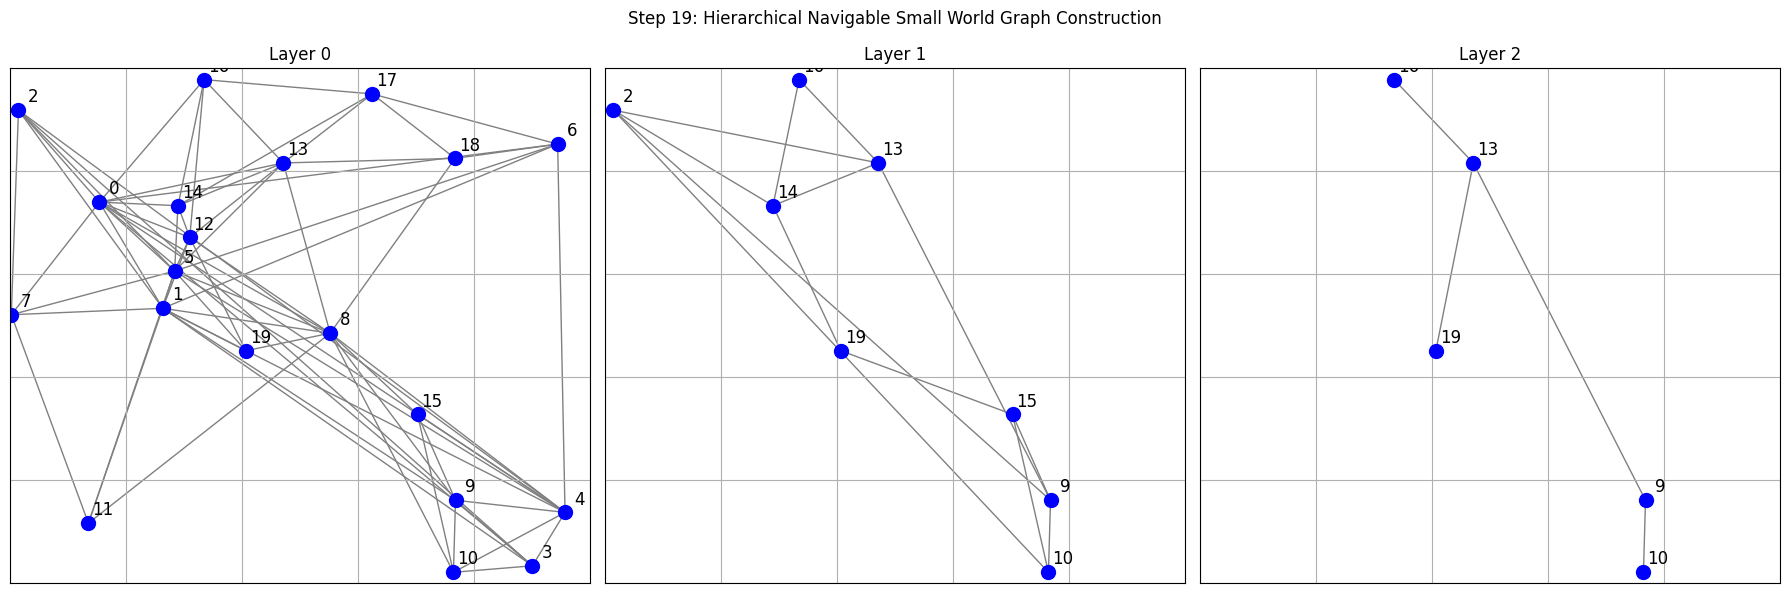

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics.pairwise import euclidean_distances
from IPython.display import clear_output
import time

# Generate a random 2D dataset
np.random.seed(12)
num_points = 20
points = np.random.rand(num_points, 2)

# Initialize empty graphs for each layer
G_layers = [nx.Graph() for _ in range(3)]

# Function to calculate the k nearest neighbors of a given point
def k_nearest_neighbors(G, point_idx, k=2):
    distances = []
    for node in G.nodes():
        if node != point_idx:
            dist = euclidean_distances([G.nodes[point_idx]['pos']], [G.nodes[node]['pos']])[0][0]
            distances.append((node, dist))
    distances.sort(key=lambda x: x[1])
    return [node for node, _ in distances[:k]]

# Function to visualize the graph at each step
def visualize_graph(G_layers, step):
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"Step {step}: Hierarchical Navigable Small World Graph Construction")

    for layer, (G, ax) in enumerate(zip(G_layers, axs)):
        # Extract positions from graph
        pos = nx.get_node_attributes(G, 'pos')

        # Draw nodes
        nx.draw_networkx_nodes(G, pos, ax=ax, node_color='blue', node_size=100)

        # Draw edges
        nx.draw_networkx_edges(G, pos, ax=ax, edge_color='gray')

        # Draw labels
        labels = {node: str(node) for node in G.nodes()}
        label_text_offset = 0.025
        label_pos = {i:(p + label_text_offset) for i, p in pos.items()}
        nx.draw_networkx_labels(G, label_pos, labels, ax=ax, font_size=12)

        ax.set_title(f"Layer {layer}")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True)

    plt.tight_layout()
    time.sleep(1)
    clear_output(wait=True)
    plt.show()

# Build the Hierarchical Navigable Small World graph incrementally
def build_hnsw_graph(points, G_layers, k_values=[4, 2, 1], m_l=1):
    for step, point in enumerate(points):

        #Choosing the top layer to add the point:
        top_layer = int(np.clip(np.floor(-np.log(np.random.uniform(0,1)*m_l)), a_min=0, a_max=len(G_layers)))
        print(top_layer)

        # Add point to the layers not higher than the top_layer
        for layer, G in enumerate(G_layers[:(top_layer+1)]):
            G.add_node(step, pos=point, label=str(step))

            if step > 0:
                # Find k nearest neighbors of the new point for this layer
                k = min(k_values[layer], step)
                neighbors = k_nearest_neighbors(G, step, k)

                # Connect the new point to its nearest neighbors in this layer
                for neighbor in neighbors:
                    G.add_edge(step, neighbor)

        # Visualize the graph at each step
        visualize_graph(G_layers, step)

# Build and visualize the Hierarchical Navigable Small World graph
build_hnsw_graph(points, G_layers, k_values=[4, 2, 1])

Now, the search:

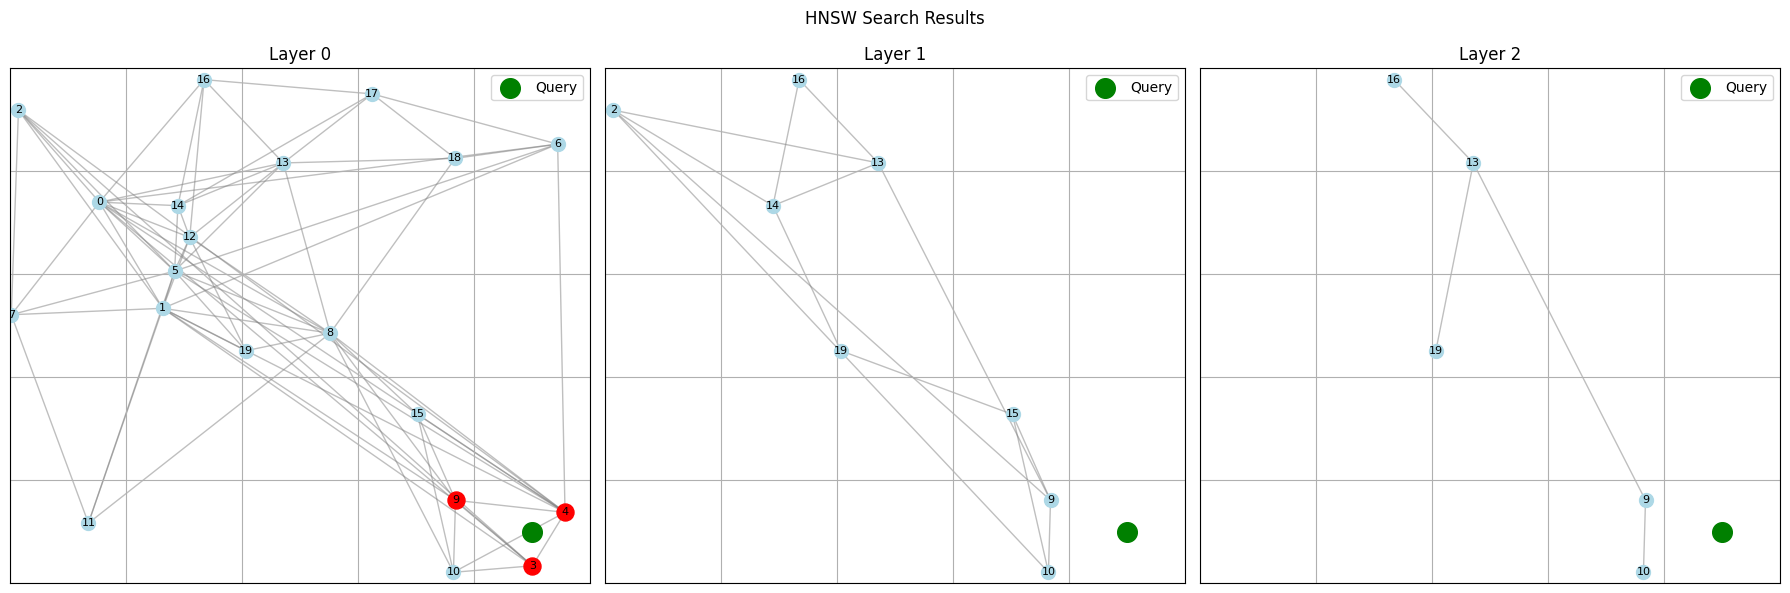

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances
import heapq

# Visualize the search results
def visualize_search_results(G_layers, query_point, nearest_neighbors, current_layer=None):
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle("HNSW Search Results")

    for layer, (G, ax) in enumerate(zip(G_layers, axs)):
        pos = nx.get_node_attributes(G, 'pos')

        # Draw nodes
        nx.draw_networkx_nodes(G, pos, ax=ax, node_color='lightblue', node_size=100)

        # Draw edges
        nx.draw_networkx_edges(G, pos, ax=ax, edge_color='gray', alpha=0.5)

        # Draw labels
        labels = {node: str(node) for node in G.nodes()}
        nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=8)

        # Highlight nearest neighbors
        if (current_layer is None and layer == 0) or layer == current_layer:
            nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=nearest_neighbors, node_color='red', node_size=150)

        # Draw query point
        ax.scatter(*query_point, color='green', s=200, zorder=3, label='Query')

        ax.set_title(f"Layer {layer}")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True)
        ax.legend()

    clear_output(wait=True)
    plt.tight_layout()
    plt.show()
    time.sleep(2)

def hnsw_search(G_layers, query_point, ef_construction=3, ef_search=3):
    def distance(node):
        return euclidean_distances([query_point], [G_layers[0].nodes[node]['pos']])[0][0]

    def search_layer(G, entry_points, ef, layer,
                     G_layers, current_layer):

        visualize_search_results(G_layers, query_point,
                                 nearest_neighbors=entry_points,
                                 current_layer=current_layer)


        # G_layers and current_layer are only needed for visualization
        v = set(entry_points)  # set of visited elements
        C = [(distance(ep), ep) for ep in entry_points]  # set of candidates
        heapq.heapify(C)
        W = [(-distance(ep), ep) for ep in entry_points]  # dynamic list of found nearest neighbors
        heapq.heapify(W)

        while C:
            c_dist, c = heapq.heappop(C)
            f_dist = -W[0][0] if len(W) > 0 else float('inf')

            #if c_dist > f_dist and len(W) >= ef:
            #    break  # all elements in W are evaluated

            for e in G[c]:
                if e not in v:
                    v.add(e)
                    e_dist = distance(e)
                    f_dist = -W[0][0] if len(W) > 0 else float('inf')

                    # print(f"e_dist: {e_dist}, f_dist: {f_dist}")
                    if e_dist < f_dist or len(W) < ef:
                        heapq.heappush(C, (e_dist, e))
                        heapq.heappush(W, (-e_dist, e))

                        if len(W) > ef:
                            heapq.heappop(W)  # remove furthest element
                    """print("Candidates:", C)
                    print("Neighbours", W)
                    time.sleep(10)"""

            visualize_search_results(G_layers, query_point,
                                     nearest_neighbors=[node for _, node in sorted(W, key=lambda x: -x[0])],
                                     current_layer=current_layer)

        return [node for _, node in sorted(W, key=lambda x: -x[0])]

    # Start with a random node in the top layer
    entry_point = np.random.choice(list(G_layers[-1].nodes()))

    entry_points = [entry_point]

    for layer in range(len(G_layers) - 1, -1, -1):
        G = G_layers[layer]
        ef = ef_search if layer == 0 else ef_construction
        entry_points = search_layer(G, entry_points, ef, layer,
                                     G_layers, current_layer=layer)
        # entry_point = entry_points[0]

    return entry_points

# Example usage:
query_point = np.array([0.9, 0.1])
nearest_neighbors = hnsw_search(G_layers, query_point)
print(f"Query point: {query_point}")
print(f"Nearest neighbors: {nearest_neighbors}")

visualize_search_results(G_layers, query_point, nearest_neighbors)

## RAG

In this demo we'll apply RAG to perform Q&A about the `transformers` library using this library's documentation.

In [ ]:
import os

with open("openai_api_key", "r") as file:
    openai_api_key = file.read().strip()

os.environ["OPENAI_API_KEY"] = openai_api_key

with open("nebius_api_key", "r") as file:
    nebius_api_key = file.read().strip()

os.environ["NEBIUS_API_KEY"] = nebius_api_key

Let's get the docs.

In [ ]:
!git clone https://github.com/huggingface/transformers

fatal: destination path 'transformers' already exists and is not an empty directory.


We're going to strip markdown from most of its structure leaving only plain text.

In [ ]:
import os
import re

from tqdm import tqdm
from bs4 import BeautifulSoup
from markdown import markdown
from pathlib import Path


def markdown_to_text(markdown_string):
    """ Converts a markdown string to plaintext """

    # md -> html -> text since BeautifulSoup can extract text cleanly
    html = markdown(markdown_string)

    html = re.sub(r'<!--((.|\n)*)-->', '', html)
    html = re.sub('<code>bash', '<code>', html)

    # extract text
    soup = BeautifulSoup(html, "html.parser")
    text = ''.join(soup.findAll(text=True))

    text = re.sub('```(py|diff|python)', '', text)
    text = re.sub('```\n', '\n', text)
    text = re.sub('-         .*', '', text)
    text = text.replace('...', '')
    text = re.sub('\n(\n)+', '\n\n', text)

    return text


def prepare_files(input_dir="transformers/docs/source/en/", output_dir="docs"):
    # Convert string paths to Path objects
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)

    # Check if input directory exists
    assert input_dir.is_dir(), "Input directory doesn't exist"
    output_dir.mkdir(parents=True, exist_ok=True)

    for root, subdirs, files in tqdm(os.walk(input_dir)):
        root_path = Path(root)
        for file_name in files:
            file_path = root_path / file_name
            parent = root_path.stem if root_path.stem != input_dir.stem else ""

            if file_path.is_file():
                with open(file_path, encoding="utf-8") as f:
                    md = f.read()
                text = markdown_to_text(md)

                output_file = output_dir / f"{parent}_{Path(file_name).stem}.txt"
                with open(output_file, "w", encoding="utf-8") as f:
                    f.write(text)


In [ ]:
prepare_files()

0it [00:00, ?it/s]<ipython-input-3-d285d05c636f>:21: DeprecationWarning: The 'text' argument to find()-type methods is deprecated. Use 'string' instead.
  text = ''.join(soup.findAll(text=True))
6it [00:10,  1.76s/it]


We will perform chunking using recursive text splitter from the `Langchain` library.

In [ ]:
!pip install lancedb pyarrow tiktoken -q
!pip install -qU langchain-text-splitters

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    separators=[
        "\n\n",
        "\n",
        ".",
        " "
    ],
    chunk_size=1024,
    chunk_overlap=128,
    length_function=len,
    is_separator_regex=False,
)

In [ ]:
import os
from typing import List
from functools import partial

import lancedb
from lancedb.pydantic import LanceModel, Vector
from lancedb.embeddings import get_registry

Let's create a LanceDB database.

In [ ]:
# This line is needed in case you've ran this cell before to clear the db dir
!rm -rf /tmp/lancedb

db = lancedb.connect("/tmp/lancedb")

In [ ]:
import openai
import pyarrow as pa

# We use this model as the encoder: https://huggingface.co/BAAI/bge-small-en-v1.5
embed_func = get_registry().get("huggingface").create(name="BAAI/bge-small-en-v1.5")


class BasicSchema(LanceModel):
      '''
    This is how we store data in the database.
    We need to have a vector here, but apart from this, we may have many other fields
    '''
    text: str = embed_func.SourceField()
    vector: Vector(embed_func.ndims()) = embed_func.VectorField(default=None)

lance_table = db.create_table(
    "transformer_docs",
    mode='overwrite',
    schema=BasicSchema
)

Let's populate the database:

In [ ]:
from tqdm import tqdm
splitted_docs = []

for file in tqdm(os.listdir("docs")):
    with open("docs/"+file, "r") as f:
        text = f.read()
        docs = text_splitter.create_documents([text])
        splitted_docs.extend([{"text": doc.page_content} for doc in docs])

100%|██████████| 456/456 [00:00<00:00, 759.60it/s]


In [ ]:
print("Total splits:", len(splitted_docs))
print("==First split:==\n", splitted_docs[0])
print("==Second split:==\n", splitted_docs[1])

Total splits: 4209
==First split:==
 page_content='Qwen2Audio
Overview
The Qwen2-Audio is the new model series of large audio-language models from the Qwen team. Qwen2-Audio is capable of accepting various audio signal inputs and performing audio analysis or direct textual responses with regard to speech instructions. We introduce two distinct audio interaction modes:

voice chat: users can freely engage in voice interactions with Qwen2-Audio without text input
audio analysis: users could provide audio and text instructions for analysis during the interaction'
==Second split:==
 page_content='It was proposed in Qwen2-Audio Technical Report by Yunfei Chu, Jin Xu, Qian Yang, Haojie Wei, Xipin Wei, Zhifang Guo, Yichong Leng, Yuanjun Lv, Jinzheng He, Junyang Lin, Chang Zhou, Jingren Zhou. 
The abstract from the paper is the following:'


In [ ]:
lance_table.add(
    [{"text": "Help!"}],
    on_bad_vectors='drop'  # or 'fill' with fill_value=0.0
)

In [ ]:
lance_table.add(
    splitted_docs,
    on_bad_vectors='drop'  # or 'fill' with fill_value=0.0
)

This function will allow us to fetch up to `limits` documents from the database for our `query`:

In [ ]:
def search_table(table, query, limit=5):
    return table.search(query).limit(limit).to_pydantic(BasicSchema)

In [ ]:
result = search_table(lance_table, "Qwen2", limit=5)
result

[BasicSchema(text='Qwen2\nOverview\nQwen2 is the new model series of large language models from the Qwen team. Previously, we released the Qwen series, including Qwen2-0.5B, Qwen2-1.5B, Qwen2-7B, Qwen2-57B-A14B, Qwen2-72B, Qwen2-Audio, etc.\nModel Details\nQwen2 is a language model series including decoder language models of different model sizes. For each size, we release the base language model and the aligned chat model. It is based on the Transformer architecture with SwiGLU activation, attention QKV bias, group query attention, mixture of sliding window attention and full attention, etc. Additionally, we have an improved tokenizer adaptive to multiple natural languages and codes.\nUsage tips\nQwen2-7B and Qwen2-7B-Instruct can be found on the Huggingface Hub\nIn the following, we demonstrate how to use Qwen2-7B-Instruct for the inference. Note that we have used the ChatML format for dialog, in this demo we show how to leverage apply_chat_template for this purpose.\nthon', vector=F

In [ ]:
result = search_table(lance_table, "How to get the damned RAG working?!", limit=5)
result

[BasicSchema(text='RAG', vector=FixedSizeList(dim=384)),
 BasicSchema(text='import gradio as gr\nfrom transformers import (\n    load_tool,\n    ReactCodeAgent,\n    HfApiEngine,\n    stream_to_gradio,\n)\nImport tool from Hub\nimage_generation_tool = load_tool("m-ric/text-to-image")\nllm_engine = HfApiEngine("meta-llama/Meta-Llama-3-70B-Instruct")\nInitialize the agent with the image generation tool\nagent = ReactCodeAgent(tools=[image_generation_tool], llm_engine=llm_engine)\ndef interact_with_agent(task):\n    messages = []\n    messages.append(gr.ChatMessage(role="user", content=task))\n    yield messages\n    for msg in stream_to_gradio(agent, task):\n        messages.append(msg)\n        yield messages + [\n            gr.ChatMessage(role="assistant", content="⏳ Task not finished yet!")\n        ]\n    yield messages\nwith gr.Blocks() as demo:\n    text_input = gr.Textbox(lines=1, label="Chat Message", value="Make me a picture of the Statue of Liberty.")\n    submit = gr.Button("

Finally, it's time to generate something!

In [ ]:
from openai import OpenAI
client = OpenAI(
    base_url="https://api.studio.nebius.ai/v1/",
    api_key=os.environ.get("NEBIUS_API_KEY"),
)

model="meta-llama/Meta-Llama-3.1-8B-Instruct"

def search_result_to_context(search_result):
    return "\n\n".join(
        [record.text for record in search_result]
    )

def answer_with_db(query,
                   client, model, verbose=False,
                   limit=5):
    search_results = search_table(lance_table, query, limit=limit)
    completion = client.chat.completions.create(
            messages=[
            {
            "role": "user",
            "content": f"""You are an AI expert. Leveraging the following context, answer the query.

CONTEXT:
{search_result_to_context(search_results)}

QUERY:
{query}
"""
                }
            ],
            model=model,
            )

    if verbose:
        return {
                "context": search_results,
                "answer": completion.choices[0].message.content
        }
    else:
        return completion.choices[0].message.content

In [ ]:
results = answer_with_db("""Why doesn't the damned Flash Attention v2 work on my T4 GPU?!
Does it ever work?! I hate! hate! hate! the damned programming!!!
""",
               client=client, model=model, verbose=True)
print(results["answer"])

My friend, I sense your frustration!

First, let's take a deep breath and understand the issue. Flash Attention 2 is a specialized CUDA kernel implementation that relies on the specific capabilities of certain NVIDIA GPUs. The compatibility list is available on the official documentation, which you should have checked before installing.

Typically, the GPUs that support Flash Attention 2 are: 

- NVIDIA Ampere (A100, A40, A30, A24)
- NVIDIA Volta (V100, Quadro GV100)
- NVIDIA Turing (T4, T4 Mobility)

If your T4 GPU is not on the list, it's likely that Flash Attention 2 won't work on your hardware.

However, if it's still not working, try the following:

1. **Upgrade your pip and CUDA versions**: Ensure you have the latest versions of pip and CUDA installed. This might resolve any compatibility issues.
2. **Verify the installation**: After installing Flash Attention 2, check that it has been installed correctly using the command: `pip show flash-attn`. If the installation failed, try t

In [ ]:
results["context"]

[BasicSchema(text='pip install -U flash-attn --no-build-isolation\nMake also sure that you have a hardware that is compatible with Flash-Attention 2. Read more about it in the official documentation of the flash attention repository. Make also sure to load your model in half-precision (e.g. torch.float16)\nTo load and run a model using Flash Attention-2, simply change the code snippet above with the following change:\ndiff\nmodel = Idefics2ForConditionalGeneration.from_pretrained(\n    "HuggingFaceM4/idefics2-8b",\n+    torch_dtype=torch.float16,    \n+    attn_implementation="flash_attention_2",\n).to(device)\nShrinking down Idefics2 using quantization\nAs the Idefics2 model has 8 billion parameters, that would require about 16GB of GPU RAM in half precision (float16), since each parameter is stored in 2 bytes. However, one can shrink down the size of the model using quantization. If the model is quantized to 4 bits (or half a byte per parameter), that requires only about 3.5GB of RAM